# Example Inference Code

In [1]:
from pathlib import Path
import sys
import os 
import torch
import numpy as np


root_dir = Path.cwd().parent.resolve()
sys.path.insert(0, str(root_dir))   

from src.run import Run
from src.imgs import Img


print("torch.version.cuda:", torch.version.cuda)
print("torch.cuda.is_available():", torch.cuda.is_available())
print("torch.cuda.device_count():", torch.cuda.device_count())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
try:
    torch.cuda.current_device()
    print("current_device(): OK")
except Exception as e:
    print("current_device() ERROR:", e)

torch.version.cuda: 12.1
torch.cuda.is_available(): True
torch.cuda.device_count(): 1
CUDA_VISIBLE_DEVICES: None
current_device(): OK


### use the Dataset and Img classes to get normalization coefficients, class names and colors, etc.


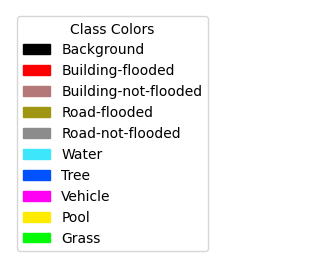

In [11]:
from datasets.floodnet import Dataset
Dataset.stats_from_yaml('floodnet.yaml')

from src.imgs import Img
img = Img(Dataset)

img.print_dataset_colors()


## Model selection

In [12]:
# comment/uncomment to choose the model you prefer, among the available ones

# from models.att_unet import sAttU_Net
# model = sAttU_Net(output_ch=len(Dataset.class_names))
# weights_path = root_dir / '.weights' /  'sattunet-fn.pth'

from models.stiramisu import sFCDenseNet103
model = sFCDenseNet103(len(Dataset.class_names))
weights_path = root_dir / '.weights' /  'stiramisu-fn.pth'


weights = torch.load(weights_path)['data']
model.load_state_dict(weights)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print('')

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"number of parameters: {total_params}")
print(f"number of trainable parameters: {trainable_params}")



number of parameters: 9321834
number of trainable parameters: 9321834


### load an input image

from a dataset object, or from a file. Comment/uncomment what you prefer

In [ ]:

###################################### from a dataset recipient

# index = 110

# from datasets.joint_transforms import JointScale
# dataset = Dataset(split='test', 
#                   scale=3000,
#                   joint_transform=JointScale(h=704, w=928),
# )
# img = Img(dataset)

# print(f'index: {index}')
# img.view(index)

# input = dataset[index][0].unsqueeze(0).to(device)

###################################### from a file

image_path = root_dir / 'notebooks' / 'sample_images' / '7420_704.jpg'
# this example image is taken from the testset of FloodNet

from PIL import Image
from IPython.display import display

display(Image.open(image_path))

def prepare(img_path, Dataset):
    img = Dataset.load_img(img_path)
    transform = Dataset.transform()
    img = transform(img)
    return img


input = prepare(image_path, Dataset)
input = input.unsqueeze(0).to(device)

print(f"input.shape {input.shape}")


### execute inference

In [6]:
print(input.shape)
with torch.no_grad():
    output = model(input)
output = output.argmax(dim=1).squeeze(0)
input = img.img_to_np(input.squeeze(0))
output = img.label_to_np(output)

torch.Size([1, 3, 704, 1052])


### use the `img` tool to visualize results

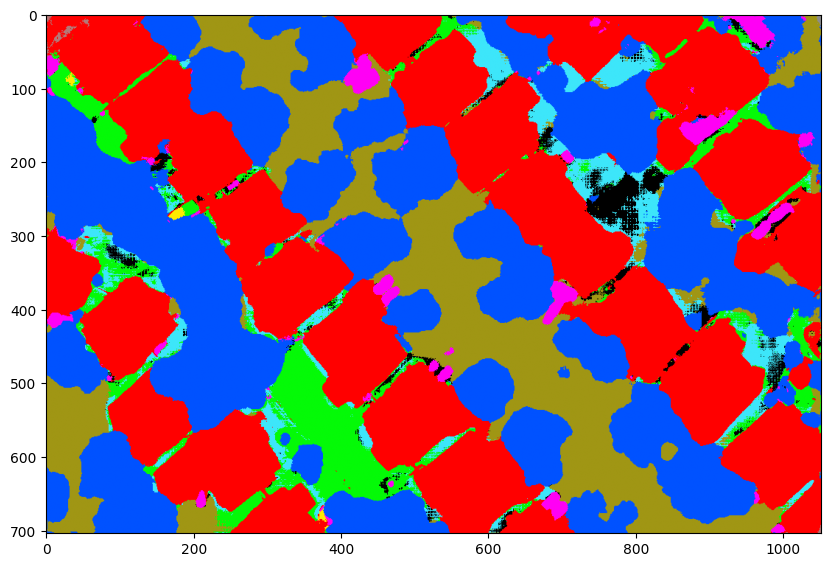

In [7]:
img.view_np(output)

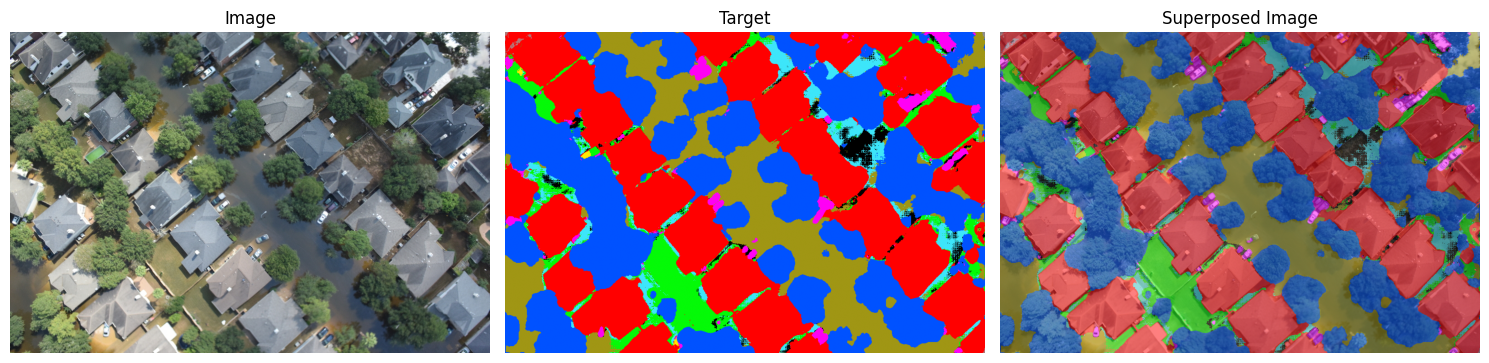

In [8]:
img.visualize_images_with_superposition(input, output)